# Cellula Technologies — Task 2: Data Preprocessing & Regression

## Uber Fare Prediction Project

**Objective:** turn the Task 1 EDA output into a leakage-safe, reusable machine-learning workflow for predicting `fare_amount`.

This notebook follows the required Task 2 sequence:

1. Missing values
2. Duplicates
3. Encoding
4. Scaling
5. Feature extraction
6. Feature selection
7. Outlier treatment
8. Train/test split
9. Cross-validation
10. Hyperparameter tuning

The source data is the cleaned positive-fare dataset produced from Task 1. The original EDA findings are used to justify the preprocessing decisions rather than repeating the full EDA.

## 1. Imports and Reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer

import joblib

RANDOM_STATE = 42
DATA_PATH = Path("data/uber_fare_eda_clean.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the Task 1 Cleaned Dataset

Task 1 identified 50,000 original rows and used **49,991 positive-fare records** for fare-based EDA. The cleaned CSV supplied for Task 2 contains those 49,991 records.

The target is `fare_amount`.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 49,991
Columns: 26


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21,4.5000,2009-06-15 17:26:21,-1.2888,0.7107,-1.2888,0.7106,1,17,15,6,0,2009,20.2658,55.1760,14.3426,34.5435,27.5726,1.0308,-2.9189
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16,16.9000,2010-01-05 16:52:16,-1.2918,0.7105,-1.2912,0.7118,1,16,5,1,1,2010,44.6677,31.8324,23.1308,15.1259,8.7557,8.4501,-0.3752
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00,5.7000,2011-08-18 00:35:00,-1.2912,0.7114,-1.2914,0.7112,2,0,18,8,3,2011,43.5977,33.7121,19.8653,17.7226,9.8473,1.3895,2.6000
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42,7.7000,2012-04-21 04:30:42,-1.2913,0.7109,-1.2914,0.7114,1,4,21,4,5,2012,42.6430,32.5563,21.0631,15.7390,7.7034,2.7993,0.1339
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00,5.3000,2010-03-09 07:51:00,-1.2910,0.7115,-1.2908,0.7118,1,7,9,3,1,2010,43.3300,39.4068,15.2193,23.7324,15.6007,1.9992,-0.5027


## 3. Data Quality Audit — Missing Values

### Decision

The supplied Task 1 cleaned dataset has no missing values. Therefore, no rows are removed and no imputed values are introduced in the current training data.

A **median imputer for numeric columns** and a **most-frequent imputer for categorical columns** are still kept inside the reusable pipeline as defensive preprocessing. This means the saved pipeline can safely handle a future input row containing a missing value without changing the training workflow.

The imputers are fitted only inside the training folds, preventing leakage.

In [3]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_summary.head(10))
print(f"Total missing cells: {int(df.isna().sum().sum()):,}")


,missing_count,missing_pct
User ID,0,0.0000
User Name,0,0.0000
Driver Name,0,0.0000
Car Condition,0,0.0000
Weather,0,0.0000
Traffic Condition,0,0.0000
key,0,0.0000
fare_amount,0,0.0000
pickup_datetime,0,0.0000
pickup_longitude,0,0.0000


Total missing cells: 0


## 4. Detecting and Removing Duplicates

Task 1 found:

- **0 exact duplicate rows**.
- The `key` field has repeated values, but Task 1 documented that these values are timestamp-like and should not be treated as a simple exact-row duplicate key.
- `key` is an identifier, not a predictive feature, so it is dropped from modeling.

This avoids using an identifier that could memorize trip records or create unstable patterns.

In [4]:
exact_duplicates = int(df.duplicated().sum())
key_duplicates = int(df["key"].duplicated().sum())

print(f"Exact duplicate rows: {exact_duplicates:,}")
print(f"Duplicated key values: {key_duplicates:,}")


Exact duplicate rows: 0
Duplicated key values: 445


## 5. Define the Modeling Features

### Features dropped

`User ID`, `User Name`, `Driver Name`, and `key` are identifiers/names rather than meaningful predictive variables.

The raw geographic coordinate columns are also excluded from the final feature set because Task 1 identified geographic-coordinate quality concerns. Airport-distance variables are retained because they are already engineered distance measures.

`pickup_datetime` is not passed directly to the model; its information is represented through deterministic time features already present in the dataset plus cyclical hour features created below.

In [5]:
TARGET = "fare_amount"

categorical_features = [
    "Car Condition",
    "Weather",
    "Traffic Condition"
]

numeric_features = [
    "passenger_count",
    "hour",
    "day",
    "month",
    "weekday",
    "year",
    "jfk_dist",
    "ewr_dist",
    "lga_dist",
    "sol_dist",
    "nyc_dist",
    "distance",
    "bearing",
    "hour_sin",
    "hour_cos"
]

model_features = categorical_features + [
    "passenger_count", "hour", "day", "month", "weekday", "year",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist",
    "distance", "bearing"
]

print("Categorical features:", categorical_features)
print("Initial numeric features:", len(model_features) - len(categorical_features))


Categorical features: ['Car Condition', 'Weather', 'Traffic Condition']
Initial numeric features: 13


## 6. Feature Extraction

Task 1 already contains `hour`, `weekday`, `month`, and `year`. Because hour is cyclical, a raw integer representation can incorrectly treat 23:00 and 00:00 as far apart.

Two deterministic features are therefore added:

- `hour_sin = sin(2π × hour / 24)`
- `hour_cos = cos(2π × hour / 24)`

This is a leakage-safe transformation because it uses only each row's existing hour value and no target-derived statistics.

In [6]:
df_model = df.copy()

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

X = df_model[categorical_features + numeric_features].copy()
y = df_model[TARGET].copy()

print(f"Modeling rows: {len(X):,}")
print(f"Modeling features before selection: {X.shape[1]:,}")
display(X.head())


Modeling rows: 49,991
Modeling features before selection: 18


,Car Condition,Weather,Traffic Condition,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,hour_sin,hour_cos
0,Very Good,windy,Congested Traffic,1,17,15,6,0,2009,20.2658,55.1760,14.3426,34.5435,27.5726,1.0308,-2.9189,-0.9659,-0.2588
1,Excellent,cloudy,Flow Traffic,1,16,5,1,1,2010,44.6677,31.8324,23.1308,15.1259,8.7557,8.4501,-0.3752,-0.8660,-0.5000
2,Bad,stormy,Congested Traffic,2,0,18,8,3,2011,43.5977,33.7121,19.8653,17.7226,9.8473,1.3895,2.6000,0.0000,1.0000
3,Very Good,stormy,Flow Traffic,1,4,21,4,5,2012,42.6430,32.5563,21.0631,15.7390,7.7034,2.7993,0.1339,0.8660,0.5000
4,Bad,stormy,Congested Traffic,1,7,9,3,1,2010,43.3300,39.4068,15.2193,23.7324,15.6007,1.9992,-0.5027,0.9659,-0.2588


## 7. Outlier Detection & Treatment

Task 1 showed a very long-tailed `distance` distribution, with a small number of extreme observations. It also showed that extreme distances can distort simple correlations.

The goal here is **not** to delete every statistical outlier. The Task 2 guidance explicitly says to distinguish rare valid observations from data-entry errors.

For this dataset:

- Positive-fare rows are retained.
- No statistical outliers are automatically deleted.
- Numeric preprocessing uses **Yeo-Johnson transformation**, which can handle zero/positive/negative values and reduces skewness.
- The final tree-based model is also less dependent on raw feature scale.

This keeps rare observations available to the model while reducing the influence of strongly skewed numeric predictors.

In [7]:
outlier_summary = pd.DataFrame({
    "metric": [
        "fare_amount max",
        "distance max",
        "distance > 50 km",
        "distance == 0"
    ],
    "value": [
        df["fare_amount"].max(),
        df["distance"].max(),
        int((df["distance"] > 50).sum()),
        int((df["distance"] == 0).sum())
    ]
})
display(outlier_summary)


,metric,value
0,fare_amount max,200.0000
1,distance max,"8,667.8188"
2,distance > 50 km,119.0000
3,distance == 0,"1,449.0000"


## 8. Train/Test Split — No Leakage

The data is split **before fitting any learned preprocessing step**.

Because the Task 1 data is a row-level ride dataset rather than a forecasting table used to predict future dates, a shuffled 80/20 split is used:

`train_test_split(test_size=0.20, random_state=42)`

All imputers, encoders, transformations, feature selection, and models are fitted only on training data through scikit-learn Pipelines.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")


Training rows: 39,992
Test rows:     9,999


## 9. Preprocessing Pipeline

### Encoding
The three categorical variables have low cardinality, so **One-Hot Encoding** is appropriate.

### Scaling / Transformation
The numeric variables include highly skewed distance-related fields. **Yeo-Johnson PowerTransformer** is used because it reduces skewness and standardizes numeric features without requiring all values to be positive.

### Feature Selection
`SelectKBest(f_regression)` is placed **inside the Pipeline**. This is important: feature selection is learned separately inside each CV training fold, so validation/test information cannot influence the selected features.

### Missing values
Median numeric imputation and most-frequent categorical imputation remain inside the same preprocessing object as a defensive measure.

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=True))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 10. Baseline Model + 5-Fold Cross-Validation

A **Ridge Regression** model is used as a regularized linear baseline.

Five-fold shuffled K-Fold cross-validation is used on the training set. The held-out test set remains untouched until final evaluation.

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0))
])

baseline_cv_rmse = -cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

baseline_metrics = {
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "RMSE": mean_squared_error(y_test, baseline_pred) ** 0.5,
    "R2": r2_score(y_test, baseline_pred)
}

print(f"Baseline 5-fold CV RMSE: {baseline_cv_rmse.mean():.4f} ± {baseline_cv_rmse.std():.4f}")
print("Baseline test metrics:")
display(pd.DataFrame([baseline_metrics], index=["Ridge baseline"]))


Baseline 5-fold CV RMSE: 7.1104 ± 0.4752
Baseline test metrics:


,MAE,RMSE,R2
Ridge baseline,4.0051,6.9963,0.4955


## 11. Tuned Regression Model

The final model is a **HistGradientBoostingRegressor**. It is suitable for nonlinear tabular relationships and can capture interactions that a simple linear model cannot.

`RandomizedSearchCV` is used with the same 5-fold CV strategy. The final test set is not used during tuning.

The feature selector is also inside the search pipeline, so selection happens within each CV fold.

In [11]:
tuned_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("select", SelectKBest(score_func=f_regression, k=12)),
    ("model", HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        early_stopping=True
    ))
])

param_distributions = {
    "select__k": [10, 12, 16, 20, "all"],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "model__max_iter": [150, 250, 350],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 40, 80],
    "model__l2_regularization": [0, 0.1, 1.0, 5.0]
}

search = RandomizedSearchCV(
    tuned_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

search.fit(X_train, y_train)

print("Best CV RMSE:", -search.best_score_)
print("Best parameters:")
display(pd.Series(search.best_params_, name="value"))


Best CV RMSE: 4.783839720305794
Best parameters:


select__k                   10.0000
model__min_samples_leaf     40.0000
model__max_leaf_nodes       15.0000
model__max_iter            250.0000
model__learning_rate         0.0800
model__l2_regularization     0.1000
Name: value, dtype: float64

## 12. Final Held-Out Test Evaluation

The final evaluation uses the 20% test set that was never used during fitting or hyperparameter tuning.

Metrics:

- **MAE** — average absolute error in dollars.
- **RMSE** — penalizes larger errors more strongly.
- **R²** — proportion of target variance explained by the model.

In [12]:
tuned_pred = search.best_estimator_.predict(X_test)

tuned_metrics = {
    "MAE": mean_absolute_error(y_test, tuned_pred),
    "RMSE": mean_squared_error(y_test, tuned_pred) ** 0.5,
    "R2": r2_score(y_test, tuned_pred)
}

results = pd.DataFrame(
    [baseline_metrics, tuned_metrics],
    index=["Baseline Ridge", "Tuned HistGradientBoosting"]
).round(4)

display(results)

print(f"Tuned 5-fold CV RMSE: {-search.best_score_:.4f}")


,MAE,RMSE,R2
Baseline Ridge,4.0051,6.9963,0.4955
Tuned HistGradientBoosting,2.2202,4.4423,0.7966


Tuned 5-fold CV RMSE: 4.7838


## 13. Results Interpretation

The tuned nonlinear model is evaluated against the same untouched test set as the baseline.

The comparison should be read as a model-development result, not as a causal claim. The EDA and preprocessing choices explain why distance/time/categorical features are retained and why identifiers and suspicious raw coordinate fields are excluded.

In [13]:
comparison = results.copy()
comparison["RMSE improvement vs baseline (%)"] = (
    (results.loc["Baseline Ridge", "RMSE"] - results["RMSE"])
    / results.loc["Baseline Ridge", "RMSE"] * 100
).round(2)

display(comparison)


,MAE,RMSE,R2,RMSE improvement vs baseline (%)
Baseline Ridge,4.0051,6.9963,0.4955,0.0000
Tuned HistGradientBoosting,2.2202,4.4423,0.7966,36.5100


## 14. Diagnostic Plots

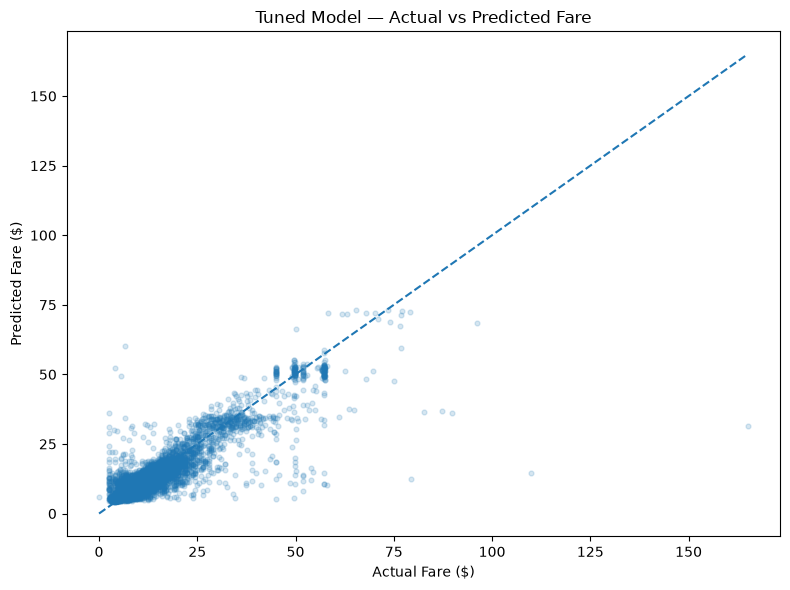

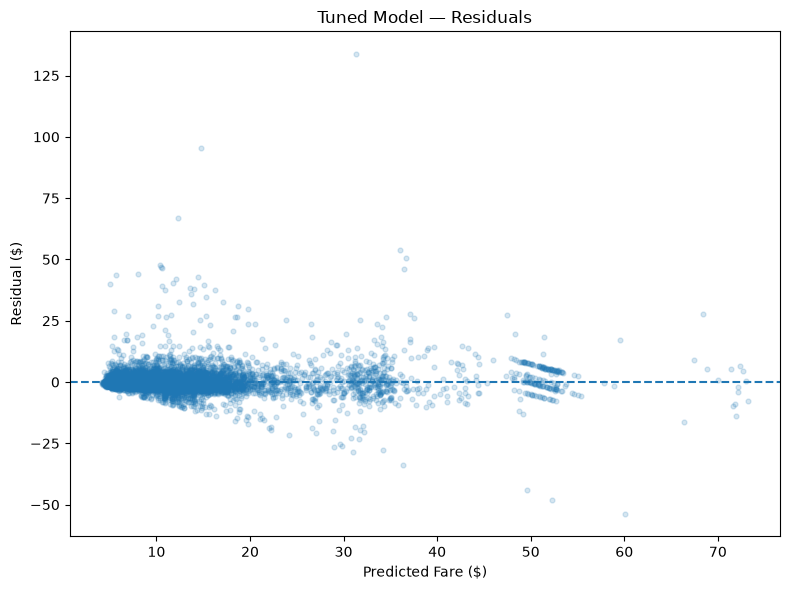

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, tuned_pred, alpha=0.18, s=12)
lims = [min(y_test.min(), tuned_pred.min()), max(y_test.max(), tuned_pred.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("Actual Fare ($)")
ax.set_ylabel("Predicted Fare ($)")
ax.set_title("Tuned Model — Actual vs Predicted Fare")
fig.tight_layout()
fig.savefig(FIG_DIR / "actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

residuals = y_test - tuned_pred
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(tuned_pred, residuals, alpha=0.18, s=12)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Fare ($)")
ax.set_ylabel("Residual ($)")
ax.set_title("Tuned Model — Residuals")
fig.tight_layout()
fig.savefig(FIG_DIR / "residuals.png", dpi=180, bbox_inches="tight")
plt.show()


## 15. Selected Feature Scores

The final pipeline selects 12 transformed features using `SelectKBest(f_regression)`.

The table below reports the selected transformed features and their univariate F-scores. These scores are used only as a feature-selection mechanism; they should not be interpreted as causal importance.

In [15]:
best_pipeline = search.best_estimator_

feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()
selector = best_pipeline.named_steps["select"]

selected_mask = selector.get_support()
selected_names = feature_names[selected_mask]
selected_scores = selector.scores_[selected_mask]

feature_scores = (
    pd.DataFrame({"feature": selected_names, "f_score": selected_scores})
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

display(feature_scores)


,feature,f_score
0,numeric__distance,"22,723.5233"
1,numeric__nyc_dist,"2,523.7581"
2,numeric__sol_dist,"1,952.6018"
3,numeric__jfk_dist,"1,776.4096"
4,numeric__ewr_dist,"1,295.9431"
5,numeric__month,31.5677
6,numeric__passenger_count,27.3847
7,numeric__hour,19.7789
8,numeric__bearing,14.9368
9,numeric__lga_dist,7.8993


## 16. Save the Single Fitted Pipeline

The Task 2 specification asks for one fitted `sklearn.pipeline.Pipeline` saved with Joblib, combining preprocessing and the final model.

The saved object below is exactly the best estimator returned by `RandomizedSearchCV`.

In [16]:
PIPELINE_PATH = Path("final_regression_pipeline.joblib")
joblib.dump(best_pipeline, PIPELINE_PATH)

print(f"Saved fitted pipeline to: {PIPELINE_PATH.resolve()}")


Saved fitted pipeline to: C:\Users\noura\Uber Fare\Task2\final_regression_pipeline.joblib


## 17. Final Submission Checklist

- [x] Missing values diagnosed and handled inside the pipeline
- [x] Exact duplicates checked
- [x] Identifier/key fields excluded from modeling
- [x] Low-cardinality categorical variables one-hot encoded
- [x] Numeric variables transformed with leakage-safe Yeo-Johnson preprocessing
- [x] Cyclical hour features engineered
- [x] Feature selection performed inside the modeling pipeline
- [x] Outliers investigated without automatic deletion
- [x] Train/test split performed before learned preprocessing
- [x] 5-fold cross-validation used
- [x] Hyperparameter tuning performed with RandomizedSearchCV
- [x] Baseline vs tuned MAE/RMSE/R² reported on the held-out test set
- [x] One fitted preprocessing + model Pipeline saved with Joblib

### What I Would Try Next

1. Compare the current one-hot encoding with leakage-safe target/frequency encoding if higher-cardinality categorical variables are introduced.
2. Compare HistGradientBoosting with Gradient Boosting / XGBoost-style models.
3. Revisit geographic features after validating the suspicious coordinate patterns identified during Task 1.
4. Consider a log-transformed target with inverse-transformed predictions if fare skewness remains a dominant error source.
